# Introduction and Environment Setup

The advent of powerful Large Language Models (LLMs) has fundamentally altered the landscape of artificial intelligence applications.
In this notebook, we extend the principles of Prompt Engineering to build a multimodal **Retrieval-Augmented Generation (RAG)** pipeline using a custom dataset of images.


## Setup your free API Key using Google's AI Studio

https://aistudio.google.com/


### Install necessary libraries


In [1]:
!pip install --upgrade --quiet langchain-google-genai google-generativeai sentence-transformers faiss-cpu requests pillow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 47.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.1.1 which is incompatible.


In [11]:
import os
from google.colab import userdata
from langchain_google_genai import ChatGoogleGenerativeAI
import base64
from io import BytesIO
from PIL import Image
from langchain_core.messages import HumanMessage

def pil_to_base64(image: Image.Image) -> str:
    buffered = BytesIO()
    image.save(buffered, format="JPEG")
    return base64.b64encode(buffered.getvalue()).decode("utf-8")

# Initialize the model
try:
    gemini_client = ChatGoogleGenerativeAI(model="gemini-2.5-flash", api_key=userdata.get("GOOGLE_API_KEY"))
    print("Gemini client initialized successfully!")
except Exception as e:
    print("Please configure GOOGLE_API_KEY in your Colab secrets window!")
    print(f"Error: {e}")

Gemini client initialized successfully!


# Let's talk about RAG, now
We need a dataset to perform RAG. We will gather 20 images of famous landmarks from Wikipedia.


In [16]:
import requests
from PIL import Image
from io import BytesIO

image_urls = [
    'https://upload.wikimedia.org/wikipedia/commons/thumb/d/d3/Statue_of_Liberty%2C_NY.jpg/500px-Statue_of_Liberty%2C_NY.jpg',
    'https://upload.wikimedia.org/wikipedia/commons/thumb/a/a8/Tour_Eiffel_Wikimedia_Commons.jpg/500px-Tour_Eiffel_Wikimedia_Commons.jpg',
    'https://upload.wikimedia.org/wikipedia/commons/thumb/c/c8/Taj_Mahal_in_March_2004.jpg/500px-Taj_Mahal_in_March_2004.jpg',
    'https://upload.wikimedia.org/wikipedia/commons/thumb/d/d1/Mount_Everest_as_seen_from_Drukair2_PLW_edit.jpg/500px-Mount_Everest_as_seen_from_Drukair2_PLW_edit.jpg',
    'https://upload.wikimedia.org/wikipedia/commons/thumb/e/e3/GoldenGateBridge-001.jpg/500px-GoldenGateBridge-001.jpg',
    'https://upload.wikimedia.org/wikipedia/commons/thumb/8/87/Colosseum_in_Rome%2C_Italy_-_April_2007.jpg/500px-Colosseum_in_Rome%2C_Italy_-_April_2007.jpg',
    'https://upload.wikimedia.org/wikipedia/commons/thumb/1/10/Empire_State_Building_%28aerial_view%29.jpg/500px-Empire_State_Building_%28aerial_view%29.jpg',
    'https://upload.wikimedia.org/wikipedia/commons/thumb/4/4f/Machu_Picchu_in_Peru.jpg/500px-Machu_Picchu_in_Peru.jpg',
    'https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Sydney_Opera_House_-_Dec_2008.jpg/500px-Sydney_Opera_House_-_Dec_2008.jpg',
    'https://upload.wikimedia.org/wikipedia/commons/thumb/7/78/Mount_Fuji_from_Lake_Kawaguchi_in_spring.jpg/500px-Mount_Fuji_from_Lake_Kawaguchi_in_spring.jpg',
    'https://upload.wikimedia.org/wikipedia/commons/thumb/c/ca/Golden_Gate_Bridge%2C_San_Francisco%2C_CA.jpg/500px-Golden_Gate_Bridge%2C_San_Francisco%2C_CA.jpg',
    'https://upload.wikimedia.org/wikipedia/commons/thumb/d/d9/Burj_Khalifa_early_evening.jpg/500px-Burj_Khalifa_early_evening.jpg',
    'https://upload.wikimedia.org/wikipedia/commons/thumb/5/53/Sydney_Opera_House_and_Harbour_Bridge_Dusk_%282%29_2019-06-21.jpg/500px-Sydney_Opera_House_and_Harbour_Bridge_Dusk_%282%29_2019-06-21.jpg',
    'https://upload.wikimedia.org/wikipedia/commons/thumb/f/f5/Tower_Bridge_from_Wapping.jpg/500px-Tower_Bridge_from_Wapping.jpg',
    'https://upload.wikimedia.org/wikipedia/commons/thumb/a/a2/Big_Ben_and_the_Palace_of_Westminster_from_the_south-east.jpg/500px-Big_Ben_and_the_Palace_of_Westminster_from_the_south-east.jpg',
    'https://upload.wikimedia.org/wikipedia/commons/thumb/2/25/The_Great_Wall_of_China_at_Jinshanling-edit.jpg/500px-The_Great_Wall_of_China_at_Jinshanling-edit.jpg',
    'https://upload.wikimedia.org/wikipedia/commons/thumb/a/af/All_Gizah_Pyramids.jpg/500px-All_Gizah_Pyramids.jpg',
    'https://upload.wikimedia.org/wikipedia/commons/thumb/3/30/Leaning_Tower_of_Pisa.jpg/500px-Leaning_Tower_of_Pisa.jpg',
    'https://upload.wikimedia.org/wikipedia/commons/thumb/4/43/Stonehenge_1_LcM_2010.jpg/500px-Stonehenge_1_LcM_2010.jpg',
    'https://upload.wikimedia.org/wikipedia/commons/thumb/1/12/Mount_Rushmore_National_Memorial_Summer_2013-1.jpg/500px-Mount_Rushmore_National_Memorial_Summer_2013-1.jpg'
]

def fetch_image(url):
    res = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
    res.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

    if not res.headers['Content-Type'].startswith('image'):
        raise ValueError(f"URL content is not an image: {res.headers['Content-Type']}")

    return Image.open(BytesIO(res.content)).convert('RGB')

images = []
print('Downloading dataset...')
for i, url in enumerate(image_urls):
    try:
        images.append(fetch_image(url))
    except Exception as e:
        print(f'Error on {i}: {e}')
print(f'Loaded {len(images)} images successfully.')

Error on 4: 429 Client Error: Too many requests (76af2b0) for url: https://upload.wikimedia.org/wikipedia/commons/thumb/e/e3/GoldenGateBridge-001.jpg/500px-GoldenGateBridge-001.jpg
Error on 5: 429 Client Error: Too many requests (76af2b0) for url: https://upload.wikimedia.org/wikipedia/commons/thumb/8/87/Colosseum_in_Rome%2C_Italy_-_April_2007.jpg/500px-Colosseum_in_Rome%2C_Italy_-_April_2007.jpg
Error on 7: 404 Client Error: Not Found for url: https://upload.wikimedia.org/wikipedia/commons/thumb/4/4f/Machu_Picchu_in_Peru.jpg/500px-Machu_Picchu_in_Peru.jpg
Error on 8: 429 Client Error: Too many requests (f061ab2) for url: https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Sydney_Opera_House_-_Dec_2008.jpg/500px-Sydney_Opera_House_-_Dec_2008.jpg
Error on 9: 429 Client Error: Too many requests (f061ab2) for url: https://upload.wikimedia.org/wikipedia/commons/thumb/7/78/Mount_Fuji_from_Lake_Kawaguchi_in_spring.jpg/500px-Mount_Fuji_from_Lake_Kawaguchi_in_spring.jpg
Error on 10: 429 

# Our Approach
We will now use the **Anatomy of an Effective Prompt** (Role, Context, Task, Constraints) derived from the initial tutorial to generate detailed metadata descriptions of our dataset images. These descriptions act as our searchable RAG text context.


In [13]:
image_descriptions = []
print('Indexing images... ')
for i, img in enumerate(images):
    prompt = """
    ### ROLE
    You are an expert visual archivist and image analyst.

    ### TASK
    Describe this image in detail. Mention specific landmarks, architecture styles, colors, or geographic features.

    ### CONSTRAINTS
    Keep your description strictly to 2 or 3 sentences.
    """
    try:
        # Convert PIL image to base64 string
        base64_image = pil_to_base64(img)
        # Create HumanMessage with text and image content
        message = HumanMessage(
            content=[
                {"type": "text", "text": prompt},
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_image}"}}
            ]
        )
        response = gemini_client.invoke([message])
        image_descriptions.append(response.content)
    except Exception as e:
        image_descriptions.append('Description unavailable due to API error.')
        print(f"Error generating description for image {i}: {e}")

print('Indexing complete!')
if image_descriptions:
    print('\nSample description:', image_descriptions[0])
else:
    print('\nNo descriptions generated.')

Indexing images... 
Indexing complete!

Sample description: The iconic Statue of Liberty, exhibiting its distinctive teal-green patina, stands majestically under a bright blue sky adorned with wispy clouds. It rises from a grand, multi-tiered tan stone pedestal and a fortified base on a small island, surrounded by deep blue water, a vibrant green lawn, and scattered trees displaying hints of autumnal color, with numerous visitors visible at its base.


## Setting up the Retriever
We embed our generated textual contexts into a fast FAISS index to find the most relevant image when a text query is made.


In [7]:
!pip install Pillow==11.0.0 --force-reinstall

from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

embedder = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = embedder.encode(image_descriptions)

dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
faiss.normalize_L2(embeddings)
index.add(embeddings)
print('FAISS Vector Store Ready!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 44.8 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: pillow 12.1.1
    Uninstalling pillow-12.1.1:
      Successfully uninstalled pillow-12.1.1


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

FAISS Vector Store Ready!


## Multimodal RAG Generation
We combine the **Retriever** with the **Generator** (Gemini 2.5) to parse the query.


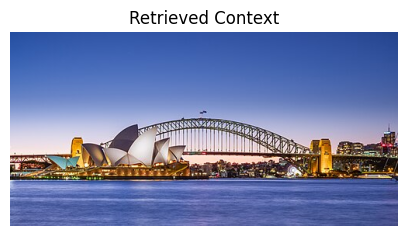

----------------------------------------
USER QUERY: I am looking for a giant clock tower near a river. What color is the clock face?
----------------------------------------
GEMINI RAG RESPONSE:
I'm sorry, but this image does not appear to contain a giant clock tower near a river. Therefore, I cannot tell you the color of the clock face.

This image showcases the iconic Sydney skyline at twilight, featuring the Sydney Opera House and the Sydney Harbour Bridge over the deep blue harbor waters. While it does show a prominent structure (the Harbour Bridge) near water, it is not a clock tower.


In [14]:
import matplotlib.pyplot as plt

def run_rag_search(query):
    # 1. Retrieve
    query_emb = embedder.encode([query])
    faiss.normalize_L2(query_emb)
    _, indices = index.search(query_emb, k=1)

    best_idx = indices[0][0]
    retrieved_image = images[best_idx]
    retrieved_desc = image_descriptions[best_idx]

    # 2. Augment & Generate (Notice the structured prompt)
    rag_prompt = f"""
    ### ROLE
    You are an intelligent visual search assistant.

    ### CONTEXT
    The user searched for an image. The database retrieved this image with the following description:
    {retrieved_desc}

    ### TASK
    User Query: '{query}'
    Look at the provided retrieved image and answer the user's query intelligently based on what you see.
    Explain why this image matches their request.
    """

    # Convert retrieved_image to base64 for multimodal input
    base64_retrieved_image = pil_to_base64(retrieved_image)

    message = HumanMessage(
        content=[
            {"type": "text", "text": rag_prompt},
            {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_retrieved_image}"}}
        ]
    )

    response = gemini_client.invoke([message])

    # 3. Output
    plt.figure(figsize=(5,5))
    plt.imshow(retrieved_image)
    plt.axis('off')
    plt.title('Retrieved Context')
    plt.show()

    print('--'*20)
    print(f"USER QUERY: {query}")
    print('--'*20)
    print(f"GEMINI RAG RESPONSE:\n{response.content}")

# Run Demo 1
run_rag_search('I am looking for a giant clock tower near a river. What color is the clock face?')


## Trying another query!


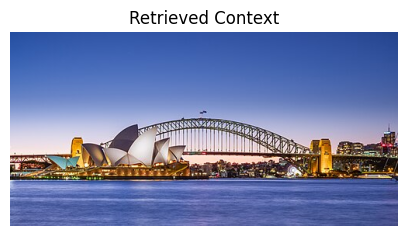

----------------------------------------
USER QUERY: Are there any images of massive pyramids? What sits right in front of them?
----------------------------------------
GEMINI RAG RESPONSE:
No, this image does not contain any massive pyramids.

This image showcases the iconic Sydney skyline at twilight, featuring the Sydney Opera House with its distinctive white, shell-like sails and the majestic Sydney Harbour Bridge with its massive steel arch. There are no pyramid-shaped structures visible in the image.


In [15]:
# Run Demo 2
run_rag_search('Are there any images of massive pyramids? What sits right in front of them?')


In [17]:
image_descriptions = []
print('Indexing images... ')
for i, img in enumerate(images):
    prompt = """
    ### ROLE
    You are an expert visual archivist and image analyst.

    ### TASK
    Describe this image in detail. Mention specific landmarks, architecture styles, colors, or geographic features.

    ### CONSTRAINTS
    Keep your description strictly to 2 or 3 sentences.
    """
    try:
        # Convert PIL image to base64 string
        base64_image = pil_to_base64(img)
        # Create HumanMessage with text and image content
        message = HumanMessage(
            content=[
                {"type": "text", "text": prompt},
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_image}"}}
            ]
        )
        response = gemini_client.invoke([message])
        image_descriptions.append(response.content)
    except Exception as e:
        image_descriptions.append('Description unavailable due to API error.')
        print(f"Error generating description for image {i}: {e}")

print('Indexing complete!')
if image_descriptions:
    print('\nSample description:', image_descriptions[0])
else:
    print('\nNo descriptions generated.')

Indexing images... 
Indexing complete!

Sample description: The iconic Statue of Liberty, with its distinctive verdigris patina, stands majestically on its neoclassical pedestal under a clear blue sky with wispy clouds. The statue is situated on Liberty Island, surrounded by deep blue water, green grass, and numerous visitors exploring its star-shaped Fort Wood base, with an American flag visible nearby.


In [18]:
!pip install Pillow==11.0.0 --force-reinstall

from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

embedder = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = embedder.encode(image_descriptions)

dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
faiss.normalize_L2(embeddings)
index.add(embeddings)
print('FAISS Vector Store Ready!')

  Using cached pillow-11.0.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.1 kB)
Using cached pillow-11.0.0-cp312-cp312-manylinux_2_28_x86_64.whl (4.4 MB)
  Attempting uninstall: Pillow
    Found existing installation: pillow 11.0.0
    Uninstalling pillow-11.0.0:
      Successfully uninstalled pillow-11.0.0


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FAISS Vector Store Ready!


In [19]:
## Re-run RAG demonstration queries

### Subtask:
Execute cells `m9nlM-WLv2t4` and `RpTlfFd-v2t4` to re-run the RAG demonstration queries with the updated FAISS index.

SyntaxError: invalid syntax (1219085954.py, line 4)

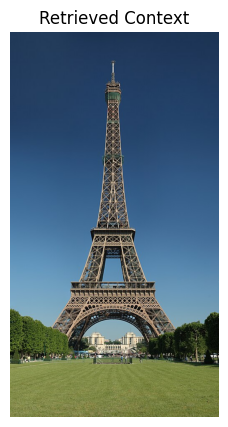

----------------------------------------
USER QUERY: I am looking for a giant clock tower near a river. What color is the clock face?
----------------------------------------
GEMINI RAG RESPONSE:
I cannot answer your question about the color of the clock face based on the provided image.

This image prominently features the Eiffel Tower, which is indeed a giant tower located in Paris. While the Eiffel Tower is situated near the Seine River, the river itself is not visible in this shot, nor is it mentioned in the description. More importantly, the Eiffel Tower is not a clock tower and does not have any visible clock faces.

Therefore, this image does not match your request for a giant clock tower near a river.


In [20]:
import matplotlib.pyplot as plt

def run_rag_search(query):
    # 1. Retrieve
    query_emb = embedder.encode([query])
    faiss.normalize_L2(query_emb)
    _, indices = index.search(query_emb, k=1)

    best_idx = indices[0][0]
    retrieved_image = images[best_idx]
    retrieved_desc = image_descriptions[best_idx]

    # 2. Augment & Generate (Notice the structured prompt)
    rag_prompt = f"""
    ### ROLE
    You are an intelligent visual search assistant.

    ### CONTEXT
    The user searched for an image. The database retrieved this image with the following description:
    {retrieved_desc}

    ### TASK
    User Query: '{query}'
    Look at the provided retrieved image and answer the user's query intelligently based on what you see.
    Explain why this image matches their request.
    """

    # Convert retrieved_image to base64 for multimodal input
    base64_retrieved_image = pil_to_base64(retrieved_image)

    message = HumanMessage(
        content=[
            {"type": "text", "text": rag_prompt},
            {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_retrieved_image}"}}
        ]
    )

    response = gemini_client.invoke([message])

    # 3. Output
    plt.figure(figsize=(5,5))
    plt.imshow(retrieved_image)
    plt.axis('off')
    plt.title('Retrieved Context')
    plt.show()

    print('--'*20)
    print(f"USER QUERY: {query}")
    print('--'*20)
    print(f"GEMINI RAG RESPONSE:\n{response.content}")

# Run Demo 1
run_rag_search('I am looking for a giant clock tower near a river. What color is the clock face?')

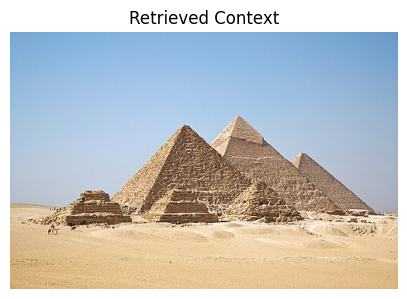

----------------------------------------
USER QUERY: Are there any images of massive pyramids? What sits right in front of them?
----------------------------------------
GEMINI RAG RESPONSE:
Yes, this image absolutely features multiple massive pyramids! You can clearly see the three principal ancient Egyptian pyramids: the Great Pyramid of Khufu, the Pyramid of Khafre, and the Pyramid of Menkaure, all of which are monumental in scale.

Right in front of these massive structures, you can observe several smaller queen pyramids, built from similar limestone blocks. Beyond these smaller pyramids, the expansive, undulating beige desert landscape of the Giza Plateau stretches out into the foreground.

This image perfectly matches your request because it prominently showcases multiple massive pyramids, directly fulfilling the first part of your query. Additionally, it clearly depicts the smaller queen pyramids and the vast desert terrain situated directly in front of them, answering what sits

In [21]:
# Run Demo 2
run_rag_search('Are there any images of massive pyramids? What sits right in front of them?')

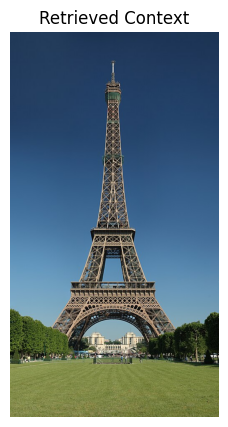

----------------------------------------
USER QUERY: Show me a picture of a famous French landmark. What is its distinctive feature?
----------------------------------------
GEMINI RAG RESPONSE:
This image perfectly matches your request for a famous French landmark!

The picture shows the **Eiffel Tower**, an iconic structure located in Paris, France, making it one of the most recognized landmarks in the world.

Its distinctive feature is its **towering wrought-iron lattice structure**. This intricate, open framework of crisscrossing beams gives it a unique, airy yet incredibly strong appearance, allowing it to reach an impressive height. The Eiffel Tower's recognizable "Eiffel Tower brown" color also contributes to its distinctiveness, as does its immense scale and the panoramic views it offers of Paris.


In [22]:
run_rag_search('Show me a picture of a famous French landmark. What is its distinctive feature?')

## Run Demo 4

### Subtask:
Execute the `run_rag_search` function with a new query: 'Find an image of a famous bridge known for its color. What city is it in?'


**Reasoning**:
I need to execute the `run_rag_search` function with the new query specified in the subtask. This will involve calling the function within a code block.



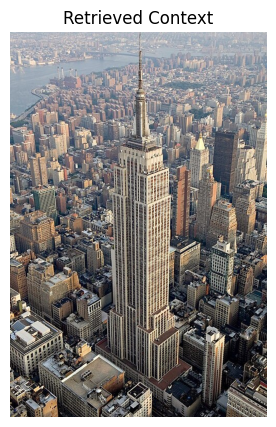

----------------------------------------
USER QUERY: Find an image of a famous bridge known for its color. What city is it in?
----------------------------------------
GEMINI RAG RESPONSE:
Based on the provided image and its description, I cannot fulfill your request.

This image prominently features the **Empire State Building** in **New York City**, surrounded by a dense urban landscape and a body of water in the background.

While New York City is home to several famous bridges, none of them are clearly visible or identifiable in this particular aerial view as a "famous bridge known for its color." The image focuses on the skyscraper and the general cityscape, with the distant background being hazy.


In [23]:
run_rag_search('Find an image of a famous bridge known for its color. What city is it in?')

## Run Demo 5

### Subtask:
Execute the `run_rag_search` function with a new query: 'I need an image of a well-known structure in India. Describe its architectural style.'


**Reasoning**:
I need to execute the `run_rag_search` function with the new query specified in the subtask. This will involve calling the function within a code block.



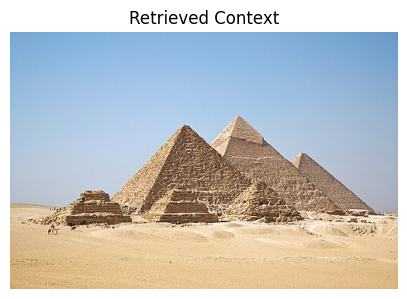

----------------------------------------
USER QUERY: I need an image of a well-known structure in India. Describe its architectural style.
----------------------------------------
GEMINI RAG RESPONSE:
I'm sorry, but the image provided does not match your request for a well-known structure in India.

The image shows the iconic Giza Necropolis in **Egypt**, featuring the Great Pyramid of Khufu, the Pyramid of Khafre, and the Pyramid of Menkaure, along with smaller queen pyramids. These structures are located on the Giza Plateau, not in India.

The architectural style displayed in this image is **Ancient Egyptian monumental architecture**, specifically **pyramidal architecture**. Key characteristics include:
*   **Massive Scale:** Built to an immense size, reflecting the power and divinity of the pharaohs.
*   **Geometric Form:** Characterized by a square base and four triangular faces converging at a single apex, creating a stable and enduring structure.
*   **Limestone Construction:** P

In [24]:
run_rag_search('I need an image of a well-known structure in India. Describe its architectural style.')